# Neuron Comparison — Reward / Money / Core
Grouped bar charts comparing Orig, ASDiv, and MMLU (all K thresholds) across 28 layers.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10

NUM_LAYERS   = 28
K_THRESHOLDS = [27, 30, 35, 40, 45, 50, 54]
LAYERS       = list(range(NUM_LAYERS))

BASE      = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1'
ORIG_DIR  = f'{BASE}/phase4/extraction'
ASDIV_DIR = f'{BASE}/evaluation/ASDiv/extraction'
MMLU_DIR  = f'{BASE}/evaluation/mmlu/neurons/mmlu'

SUBJECTS = [
    'abstract_algebra','anatomy','astronomy','business_ethics',
    'clinical_knowledge','college_biology','college_computer_science',
    'college_mathematics','college_medicine','computer_security',
    'conceptual_physics','econometrics','electrical_engineering',
    'elementary_mathematics','formal_logic','global_facts',
    'high_school_biology','high_school_chemistry','high_school_computer_science',
    'high_school_european_history','high_school_geography',
    'high_school_government_and_politics','high_school_macroeconomics',
    'high_school_mathematics','high_school_microeconomics','high_school_physics',
    'high_school_psychology','high_school_statistics','high_school_us_history',
    'high_school_world_history','human_aging','human_sexuality',
    'international_law','jurisprudence','logical_fallacies','machine_learning',
    'management','marketing','medical_genetics','miscellaneous','moral_disputes',
    'moral_scenarios','nutrition','philosophy','prehistory',
    'professional_accounting','professional_law','professional_medicine',
    'professional_psychology','public_relations','security_studies','sociology',
    'virology','world_religions'
]

print('Config ready.')

Config ready.


In [2]:
# ── Load helpers ────────────────────────────────────────────────────────────

def load_set(path):
    df = pd.read_csv(path)
    return set(zip(df['layer'].tolist(), df['neuron'].tolist()))

def layer_counts(neuron_set):
    """Returns list of length NUM_LAYERS with neuron counts per layer."""
    c = defaultdict(int)
    for (l, _) in neuron_set:
        c[l] += 1
    return [c.get(l, 0) for l in LAYERS]

# ── Load Orig ────────────────────────────────────────────────────────────────
orig_reward = load_set(f'{ORIG_DIR}/universal_reward_neurons.csv')
orig_money  = load_set(f'{ORIG_DIR}/universal_money_neurons.csv')
orig_core   = load_set(f'{ORIG_DIR}/master_incentive_core.csv')

# ── Load ASDiv ───────────────────────────────────────────────────────────────
asdiv_reward = load_set(f'{ASDIV_DIR}/asdiv_universal_reward_neurons.csv')
asdiv_money  = load_set(f'{ASDIV_DIR}/asdiv_universal_money_neurons.csv')
asdiv_core   = load_set(f'{ASDIV_DIR}/asdiv_master_incentive_core.csv')

# ── Load MMLU per-subject ────────────────────────────────────────────────────
print('Loading MMLU per-subject files...')
mmlu_per_subject = {}
for subj in SUBJECTS:
    mmlu_per_subject[subj] = {
        'reward': load_set(f'{MMLU_DIR}/per_subject/{subj}/reward.csv'),
        'money':  load_set(f'{MMLU_DIR}/per_subject/{subj}/money.csv'),
        'core':   load_set(f'{MMLU_DIR}/per_subject/{subj}/core.csv'),
    }

print(f'Orig   — reward: {len(orig_reward):>6}, money: {len(orig_money):>6}, core: {len(orig_core):>6}')
print(f'ASDiv  — reward: {len(asdiv_reward):>6}, money: {len(asdiv_money):>6}, core: {len(asdiv_core):>6}')
print(f'MMLU per-subject loaded: {len(mmlu_per_subject)} subjects')

Loading MMLU per-subject files...
Orig   — reward:   5558, money:   5467, core:   3528
ASDiv  — reward:  11517, money:  12302, core:   7913
MMLU per-subject loaded: 54 subjects


In [4]:
# ── Compute MMLU reward/money/core at each K ─────────────────────────────────
# For each neuron, count how many subjects it appears in for reward / money / core

print('Computing cross-subject counts for reward, money, core...')

reward_counts = defaultdict(int)
money_counts  = defaultdict(int)
core_counts   = defaultdict(int)

for subj in SUBJECTS:
    for n in mmlu_per_subject[subj]['reward']:
        reward_counts[n] += 1
    for n in mmlu_per_subject[subj]['money']:
        money_counts[n] += 1
    for n in mmlu_per_subject[subj]['core']:
        core_counts[n] += 1

def mmlu_set_at_k(counts_dict, k):
    return {neuron for neuron, cnt in counts_dict.items() if cnt >= k}

mmlu_k_reward = {k: mmlu_set_at_k(reward_counts, k) for k in K_THRESHOLDS}
mmlu_k_money  = {k: mmlu_set_at_k(money_counts,  k) for k in K_THRESHOLDS}
mmlu_k_core   = {k: mmlu_set_at_k(core_counts,   k) for k in K_THRESHOLDS}

print(f'\n{ "K":>4}  {"Reward":>8}  {"Money":>8}  {"Core":>8}')
print('-' * 36)
for k in K_THRESHOLDS:
    print(f'{k:>4}  {len(mmlu_k_reward[k]):>8}  {len(mmlu_k_money[k]):>8}  {len(mmlu_k_core[k]):>8}')

Computing cross-subject counts for reward, money, core...

   K    Reward     Money      Core
------------------------------------
  27      8471      8594      5881
  30      7411      7554      5123
  35      5883      5915      4011
  40      4364      4327      2927
  45      2885      2900      1870
  50      1338      1352       867
  54       289       304       177


In [5]:
# ── Plotting function ─────────────────────────────────────────────────────────

COLORS = {
    'orig':  '#4878CF',
    'asdiv': '#6ACC65',
    'mmlu':  '#D65F5F',
}

def plot_comparison_group(k, ax_reward, ax_money, ax_core):
    """
    Draws grouped bar charts for reward, money, core
    comparing orig, asdiv, mmlu_k side by side per layer.
    """
    sets = [
        ('Orig',           orig_reward,        orig_money,        orig_core,        COLORS['orig']),
        ('ASDiv',          asdiv_reward,        asdiv_money,        asdiv_core,      COLORS['asdiv']),
        (f'MMLU K={k}',   mmlu_k_reward[k],   mmlu_k_money[k],   mmlu_k_core[k],   COLORS['mmlu']),
    ]

    n_groups = 3
    bar_w    = 0.26
    x        = np.array(LAYERS)
    offsets  = [-bar_w, 0, bar_w]

    for ax, condition_idx, title in [
        (ax_reward, 1, 'Reward neurons'),
        (ax_money,  2, 'Money neurons'),
        (ax_core,   3, 'Core neurons (Reward ∩ Money)'),
    ]:
        for (label, sr, sm, sc, color), offset in zip(sets, offsets):
            s = [sr, sm, sc][condition_idx - 1]
            counts = layer_counts(s)
            ax.bar(x + offset, counts, bar_w,
                   label=f'{label} (n={len(s):,})',
                   color=color, edgecolor='white', linewidth=0.3, alpha=0.9)

        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Layer', fontsize=9)
        ax.set_ylabel('Neuron count', fontsize=9)
        ax.set_xticks(LAYERS)
        ax.set_xticklabels(LAYERS, fontsize=7)
        ax.axvspan(7.5, 14.5, alpha=0.07, color='red')   # L8-14 band
        ax.axvline(13,  color='red',  linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(27,  color='navy', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.legend(fontsize=8, loc='upper right')
        ax.tick_params(axis='y', labelsize=8)

print('Plot function ready.')

Plot function ready.


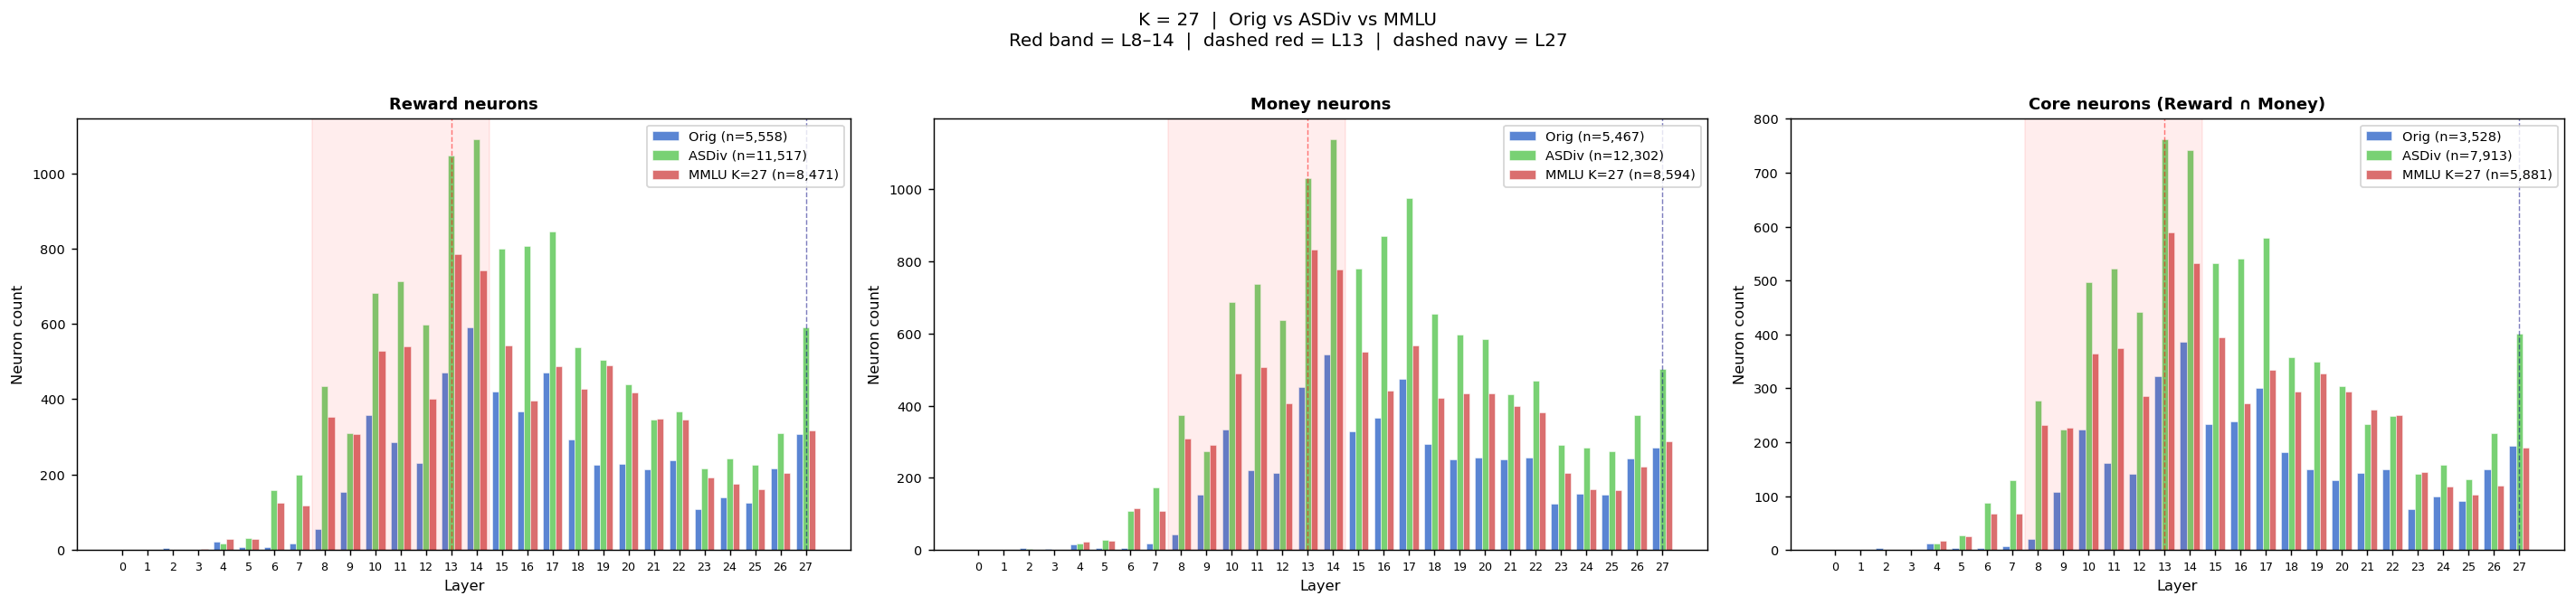

K=27 saved → comparison_k27.png


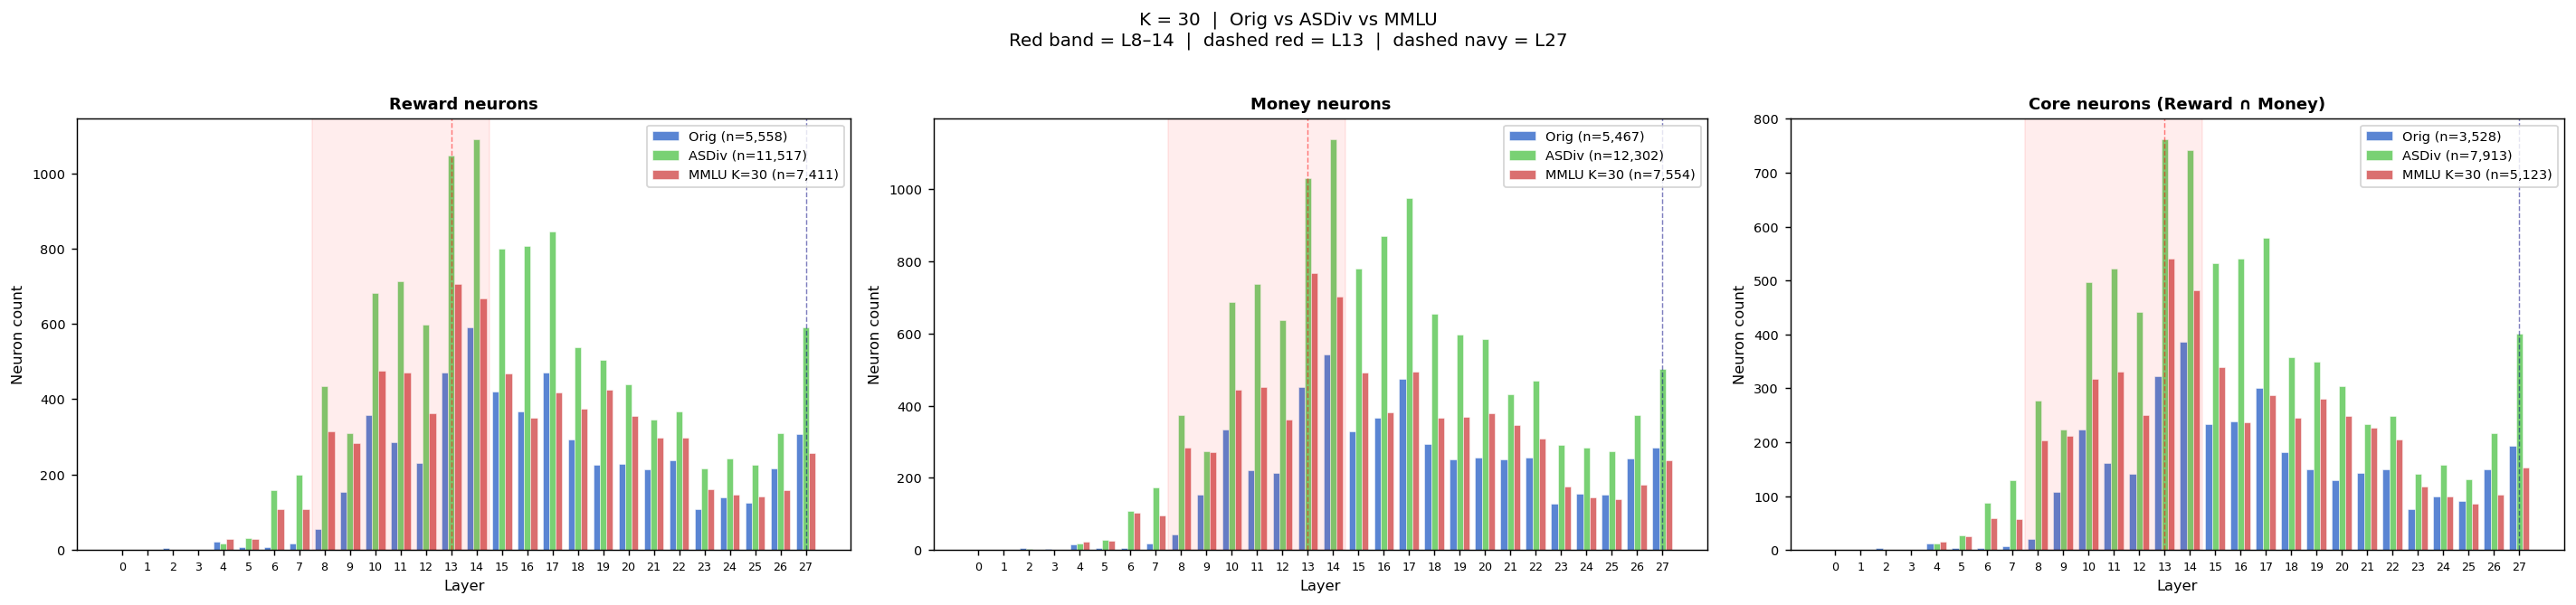

K=30 saved → comparison_k30.png


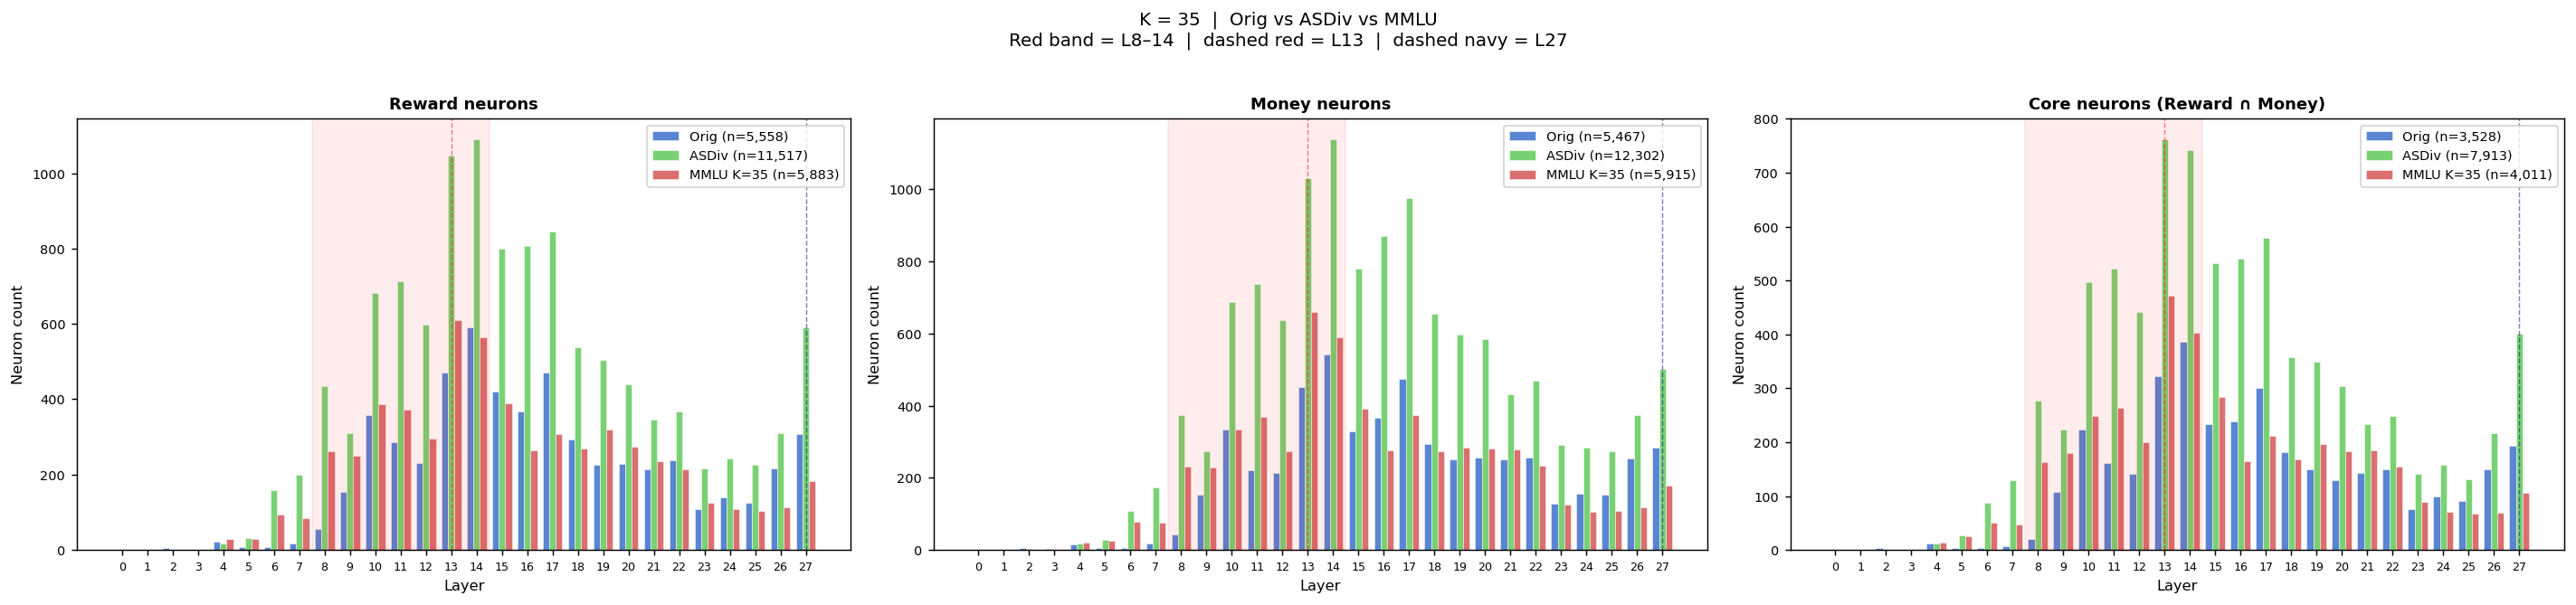

K=35 saved → comparison_k35.png


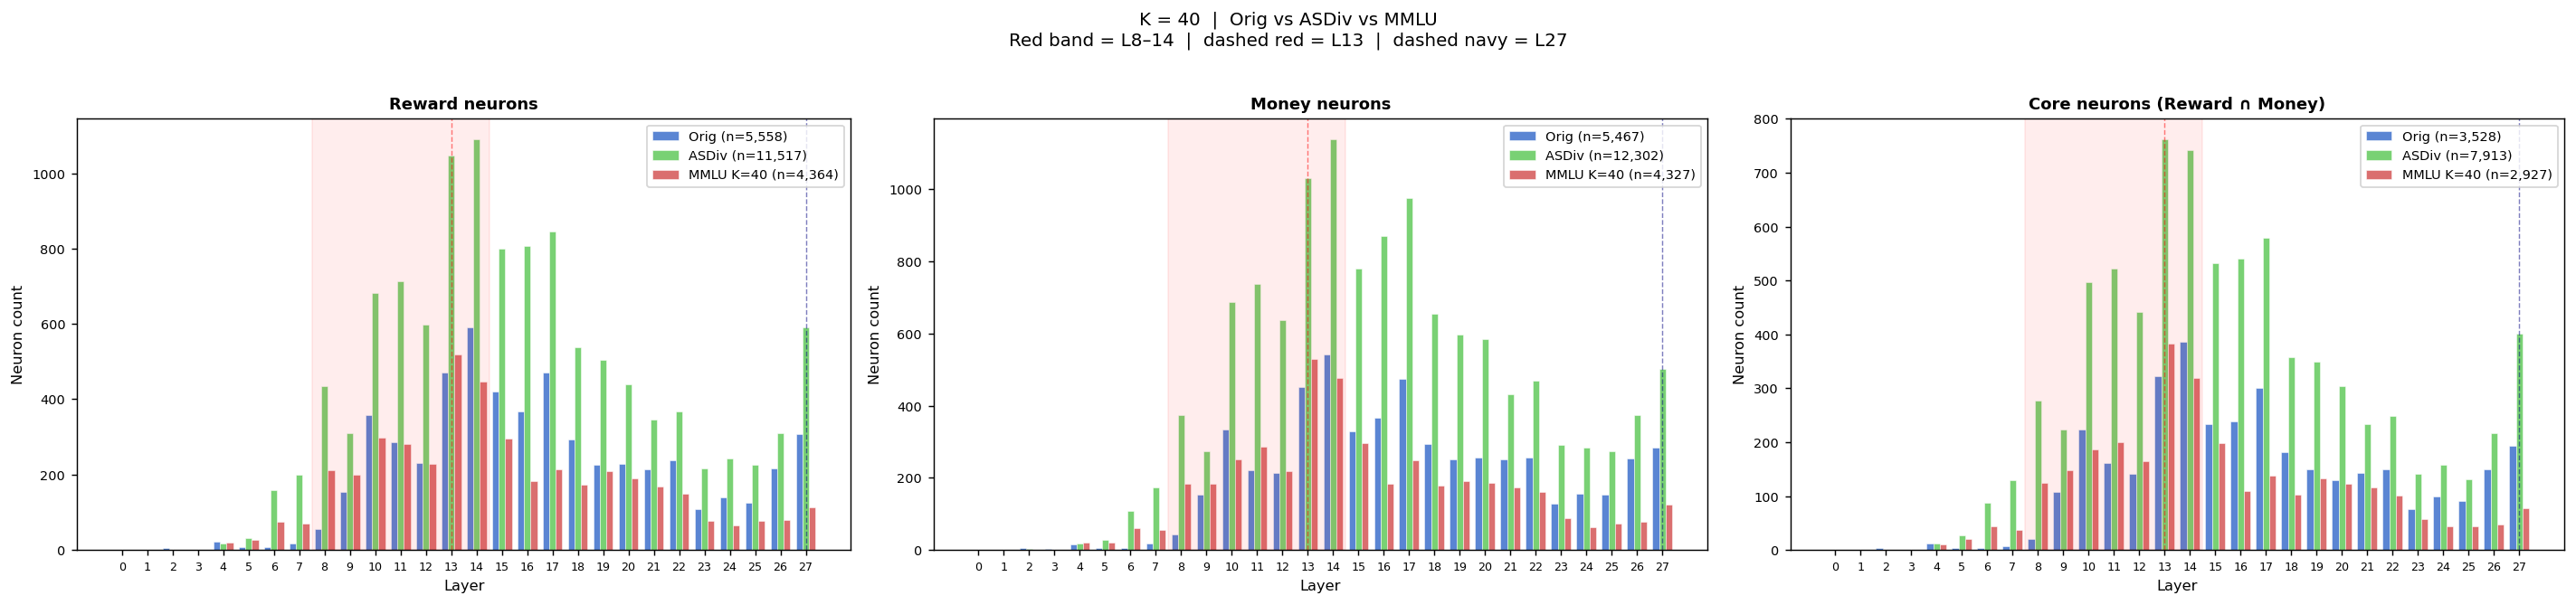

K=40 saved → comparison_k40.png


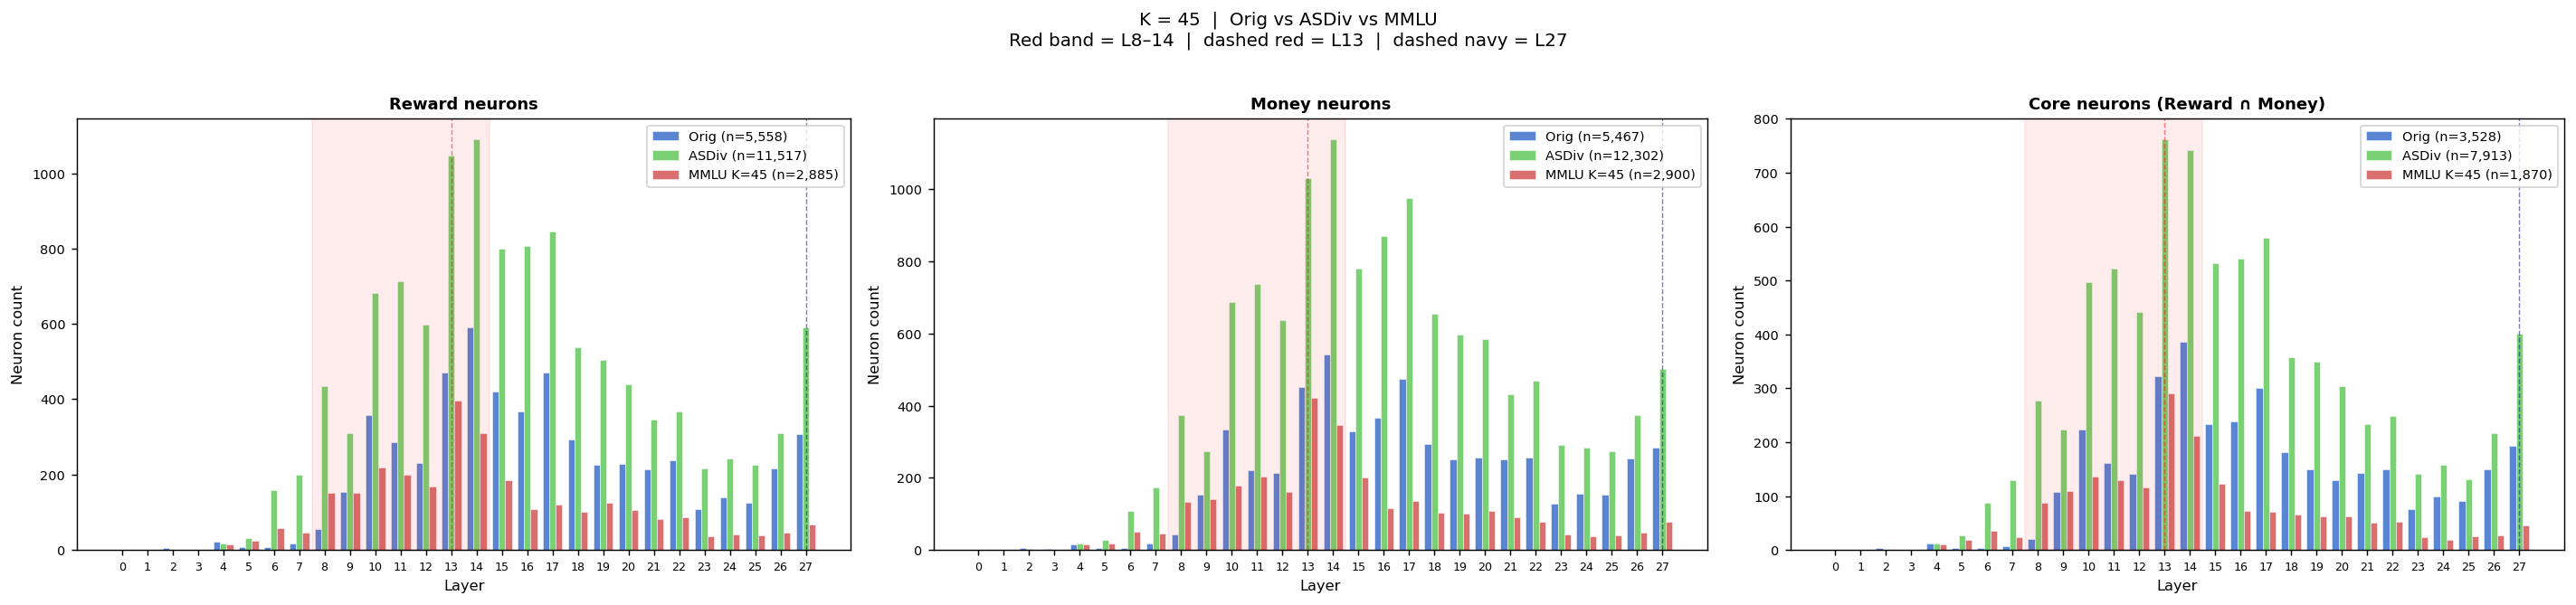

K=45 saved → comparison_k45.png


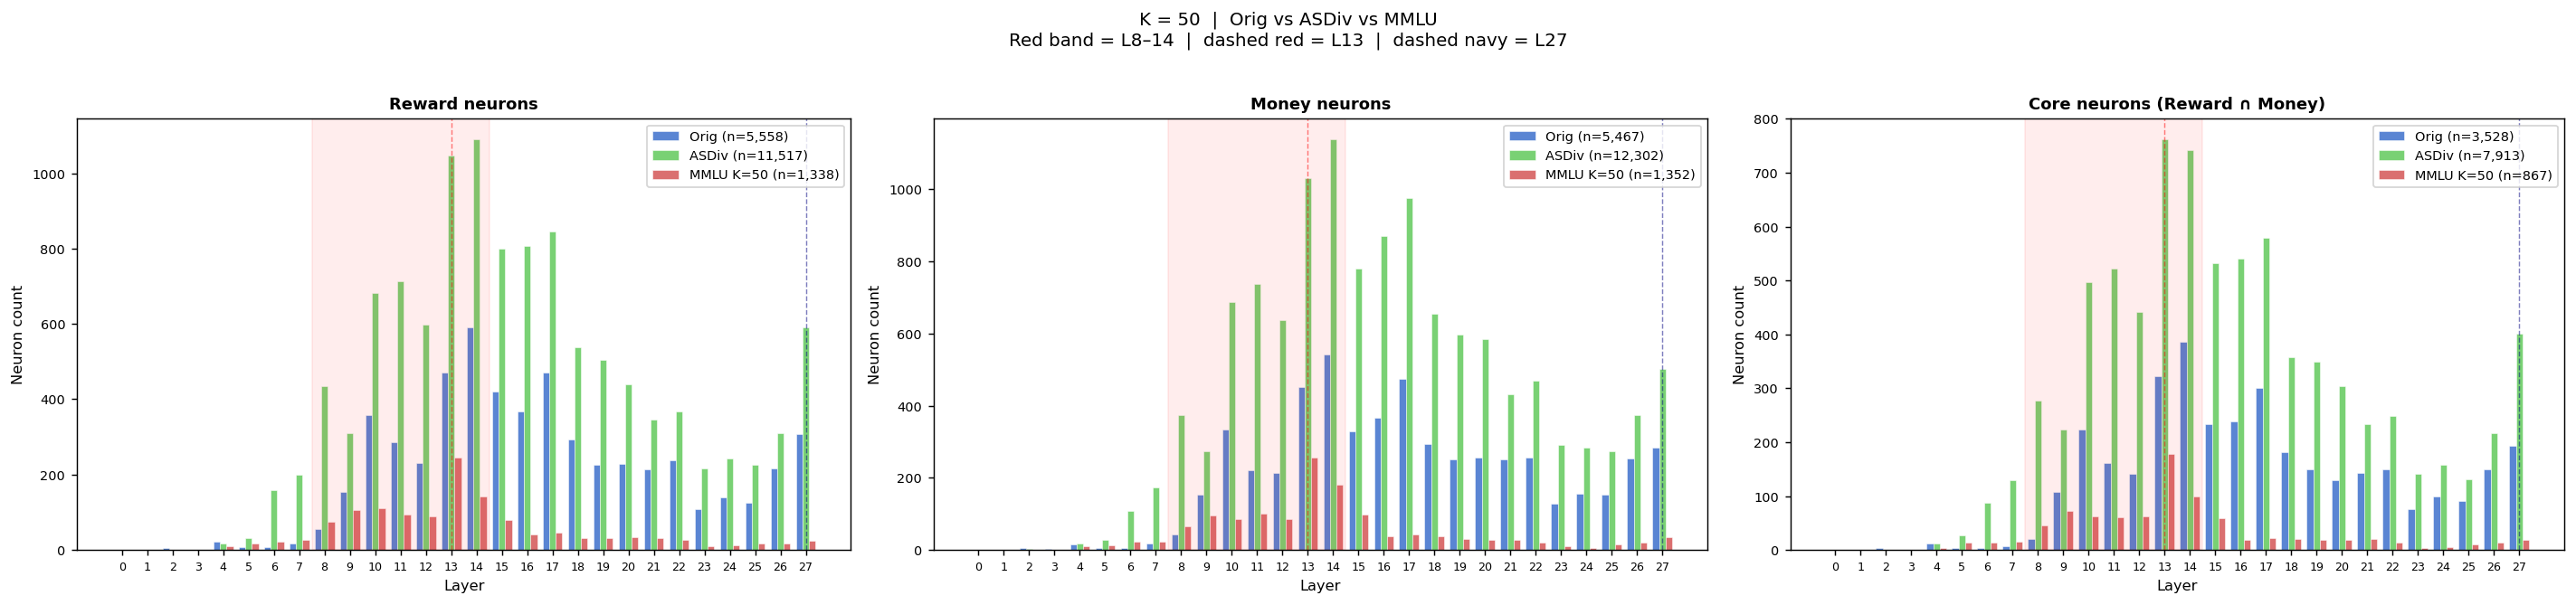

K=50 saved → comparison_k50.png


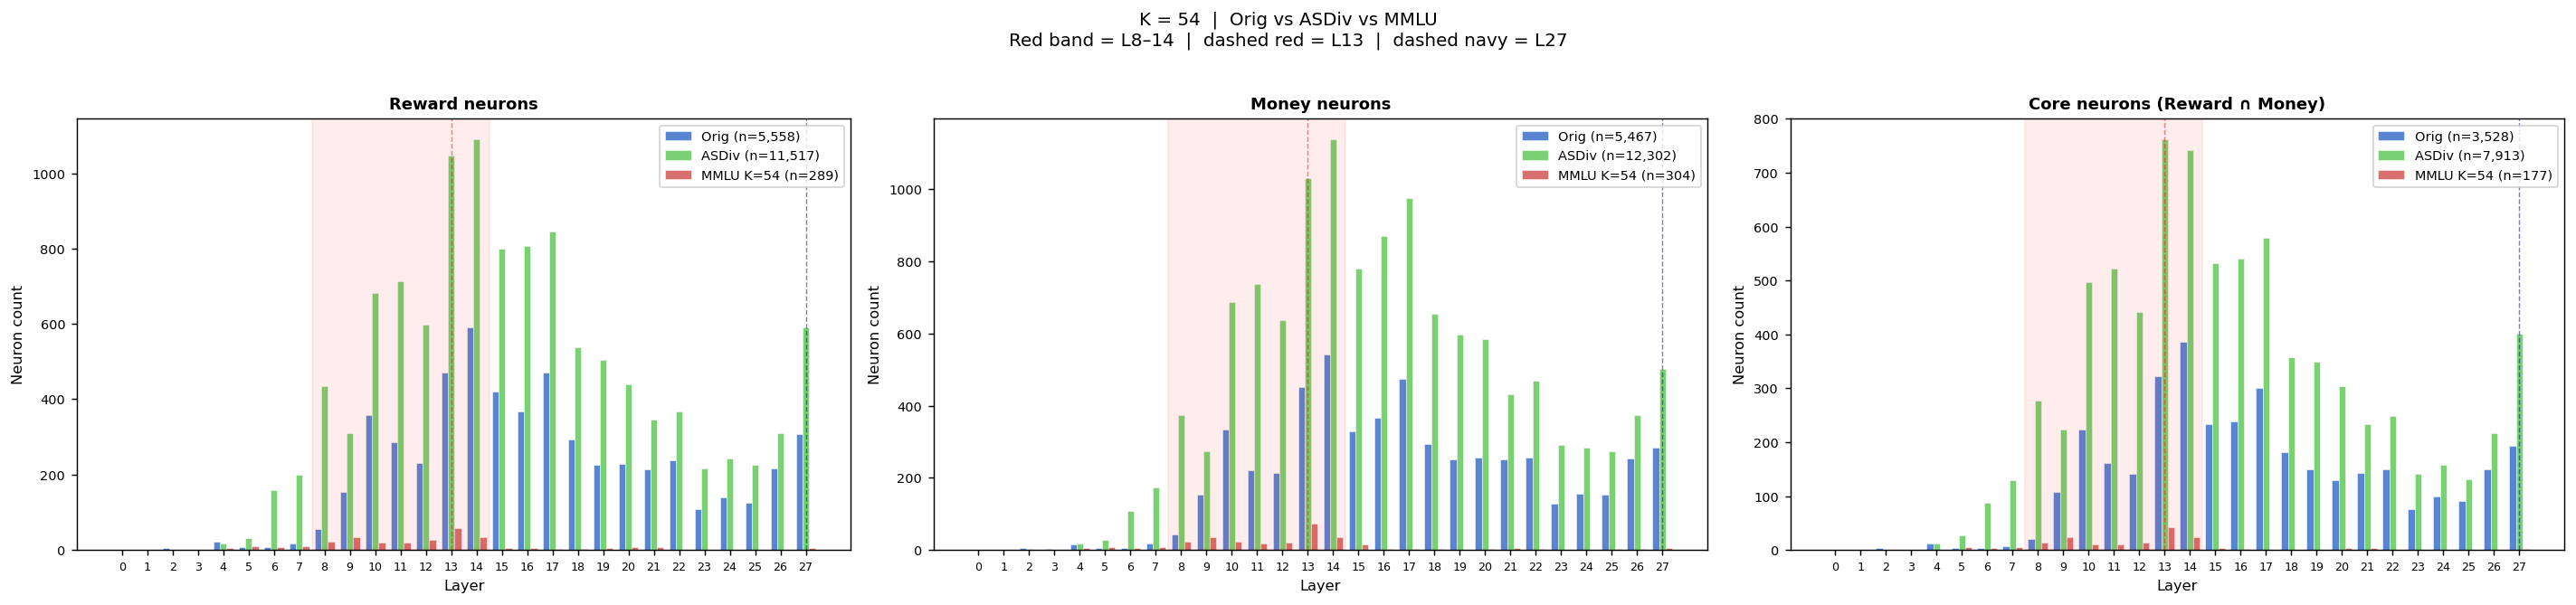

K=54 saved → comparison_k54.png


In [6]:
# ── Generate one figure per K ─────────────────────────────────────────────────

for k in K_THRESHOLDS:
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    fig.suptitle(
        f'K = {k}  |  Orig vs ASDiv vs MMLU\n'
        f'Red band = L8–14  |  dashed red = L13  |  dashed navy = L27',
        fontsize=11, y=1.02
    )

    plot_comparison_group(k, axes[0], axes[1], axes[2])

    plt.tight_layout()
    plt.savefig(f'comparison_k{k}.png', bbox_inches='tight', dpi=130)
    plt.show()
    print(f'K={k} saved → comparison_k{k}.png')

In [7]:
# ── Summary: layer 13 and layer 27 counts across all K ───────────────────────

def l_count(s, layer):
    return sum(1 for (l, _) in s if l == layer)

print(f"{'Set':<20} {'Size':>7}  {'L13 reward':>10}  {'L13 money':>10}  {'L13 core':>9}  {'L27 core':>9}")
print('-' * 75)

# Orig
print(f"{'Orig':<20} {'':>7}  {l_count(orig_reward,13):>10}  {l_count(orig_money,13):>10}  {l_count(orig_core,13):>9}  {l_count(orig_core,27):>9}")
# ASDiv
print(f"{'ASDiv':<20} {'':>7}  {l_count(asdiv_reward,13):>10}  {l_count(asdiv_money,13):>10}  {l_count(asdiv_core,13):>9}  {l_count(asdiv_core,27):>9}")
# MMLU at each K
for k in K_THRESHOLDS:
    label = f'MMLU K={k}'
    cr, cm, cc = mmlu_k_reward[k], mmlu_k_money[k], mmlu_k_core[k]
    print(f"{label:<20} {len(cc):>7}  {l_count(cr,13):>10}  {l_count(cm,13):>10}  {l_count(cc,13):>9}  {l_count(cc,27):>9}")

Set                     Size  L13 reward   L13 money   L13 core   L27 core
---------------------------------------------------------------------------
Orig                                 470         451        322        194
ASDiv                               1047        1030        762        401
MMLU K=27               5881         785         832        589        190
MMLU K=30               5123         705         767        541        153
MMLU K=35               4011         610         661        471        106
MMLU K=40               2927         519         529        382         77
MMLU K=45               1870         397         422        291         46
MMLU K=50                867         244         256        178         18
MMLU K=54                177          59          74         42          2
